<a href="https://colab.research.google.com/github/HanTanto/general_insurance/blob/main/Simulasi_Agregate_Klaim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Hani Tustanto

Nim : 20924005

---



---



# **A. Apakah agregat kerugian $X_1+X_2+...+X_N$ identik dengan $NX$?**

Misalkan $N(X_i)$ merupakan peubah acak yang menyatakan banyak klaim (besar klaim ke-$i$). $X_i$ saling bebas dan identik mengikuti distribusi $X$, serta $X$ saling bebas dengan $N$.

1. Model $S_N =X_1+X_2+...+X_N$

Definisikan $S_N$ sebagai peubah acak agregat klaim yang diformulasikan sebagai berikut.
\begin{align}
S_N=X_1+X_2+...+X_N
\end{align}
Dengan $S_N=0$ saat $N=0$. Dengan mudah dapat dicari fungsi pembangkit momen dari $S_N$\
\begin{align}
M_{S_N}(t) &=E[e^{t\sum_{i=1}^{N} X_i}] \\
&=E[\prod_{i=1}^{N}e^{tX_i}] \\
&=E[E[\prod_{i=1}^{N}e^{tX_i}\mid N]] \\
&= E[\prod_{i=1}^{N} E[e^{tX_i}\mid N]] \\
&= E[\prod_{i=1}^{N} E[e^{tX}]] \\
&= E[(M_X(t))^N] \\
&= E[e^{log(M_X(t))N}] \\
& = M_N(log(M_X(t)))
\end{align}
Momen pertama dan variansi dari $S_N$ (berdasarkan hasil sebelumnya) yaitu
\begin{align}
E[S_N]&=E[X]E[N] \\
Var (S_N) &= E[N]Var(X)+Var(N)E[X]^2
\end{align}

2. Model $S^{(2)}_N=NX$


Definisikan $S^{(2)}_N = NX$ dengan $X$ dan $N$ saling bebas, maka fungsi pembangkit momen dari $S^{(2)}_N$ yaitu
\begin{align}
M_{S^{(2)}_N}(t)&=E[e^{tNX}] \\
&= E[E[e^{tNX}\mid N]] \\
&=  E[E[e^{(tN)X}\mid N]] \\
&= E[M_X(tN)]
\end{align}
Momen pertama dan variansi dari $S^{(2)}_N$ yaitu
\begin{align}
E[S^{(2)}_N] &= E[NX] \\
&= E[N]E[X]
\end{align}
\begin{align}
Var(S^{(2)}_N) &= E[(NX)^2]-(E[NX])^2 \\
&= E[N^2X^2]-(E[N])^2(E[X])^2 \\
&= E[N^2]E[X^2]-E[N]^2E[X]^2 \\
&= (Var(X)+E[X]^2)E[N^2]-E[N]^2E[X]^2 \\
&= E[N^2]Var(X)+E[X]^2(E[N^2]-E[N]^2) \\
&= E[N^2]Var(X)+Var(N)E[X]^2
\end{align}

Karena fungsi pembangkit momennya tidak sama, maka distribusi $S_N$ `tidak sama (identik)` dengan dengan distribusi $S^{(2)}_N$


Telah ditunjukan bahwa $S_N$ memiliki distribusi yang berbeda dengan $S^{(2)}_N$ meskipun $X_i$ *iid* dan $X_i$ saling bebas dengan $N$. Berikut akan dilakukan simulasi sebanyak $1000000$ kali untuk melihat perbedaan distribusi tersebut. Misalkan $N\sim Poisson (2)$ dan $X_i \sim Eksp(1/100)$. Berikut merupakan visualisasi fungsi peluang dari model agregat kerugian tersebut

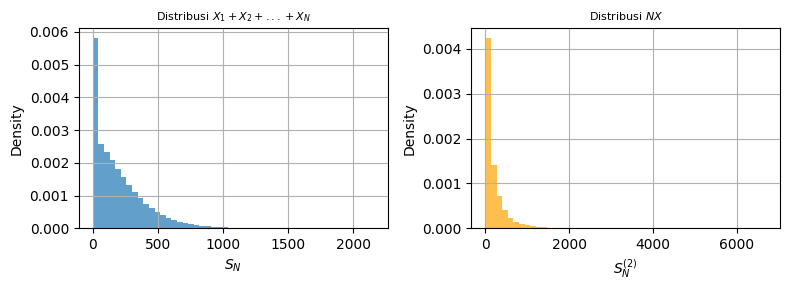

In [ ]:
# @title Default title text
import numpy as np
import matplotlib.pyplot as plt

# Generate random samples
n_samples = 1000000
poisson_samples = np.random.poisson(2, n_samples)
exponential_samples = np.random.exponential(100, n_samples)

# Calculate S_N and NX
s_n_samples = []
nx_samples = poisson_samples * exponential_samples

for n in poisson_samples:
  if n == 0:
    s_n_samples.append(0)
  else:
    # Generate n exponential samples and sum them up
    sum_x = np.sum(np.random.exponential(100, n))
    s_n_samples.append(sum_x)

# Convert to numpy arrays for easier plotting
s_n_samples = np.array(s_n_samples)
nx_samples = np.array(nx_samples)

# Plotting
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(s_n_samples, bins=50, density=True, alpha=0.7, label='$S_N$')
plt.title('Distribusi $X_1+X_2+...+X_N$', size=8)
plt.xlabel('$S_N$')
plt.ylabel('Density')
#plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.hist(nx_samples, bins=50, density=True, alpha=0.7, color='orange')#, label='$NX$')
plt.title('Distribusi $NX$', size=8)
plt.xlabel('$S^{(2)}_N$')
plt.ylabel('Density')
#plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Perhatikan bahwa, distribusi agregat kerugian model 2 memiliki ekor kanan yang lebih panjang dibandingkan distribusi agregat kerugian model 1. Dengan kata lain, pada selang kepercayaan yang sama, potensi agregat kerugian terbesar pada model 2 lebih besar dariada model 1. Berikut merupakan visualisasi fungsi distribusi dari kedua model agregat tersebut.

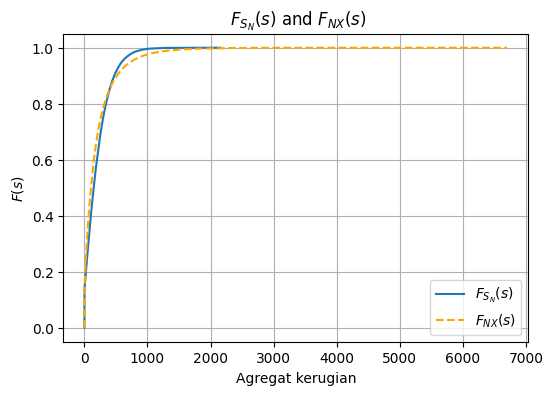

In [ ]:
# @title Default title text
plt.figure(figsize=(6, 4))

# Cumulative distribution for s_n_samples
sorted_s_n = np.sort(s_n_samples)
cumulative_s_n = np.arange(len(sorted_s_n)) / float(len(sorted_s_n))
plt.plot(sorted_s_n, cumulative_s_n, label='$F_{S_N}(s)$')

# Cumulative distribution for nx_samples
sorted_nx = np.sort(nx_samples)
cumulative_nx = np.arange(len(sorted_nx)) / float(len(sorted_nx))
plt.plot(sorted_nx, cumulative_nx, label='$F_{NX}(s)$', linestyle='--', color='orange')

plt.title(' $F_{S_N}(s)$ and $F_{NX}(s)$')
plt.xlabel('Agregat kerugian')
plt.ylabel('$F(s)$')
plt.legend()
plt.grid(True)
plt.show()

Terdapat hal menarik pada fungsi distribusi $S_N$ dan $S^{(2)}_N$. Pada kasus ini, terdapat titik ($p$) pada selang kepercayaan antara $0.8$ s.d $0.9$ sehingga terdapat pembalikan nilai fungsi distribusi. Awalnya, $F_{NX}(s)>F_{S_N}(s)$ saat $F(s)< p$ kemudian $F_{NX}(s)<F_{S_N}(s)$ saat $F(s)>p$. Hal ini akan berdampak pada nilai kuantil atau *Value-at-Risk* dari kedua distribusi tersebut. Berikut merupakan titik visualisasi titik balik tersebut.

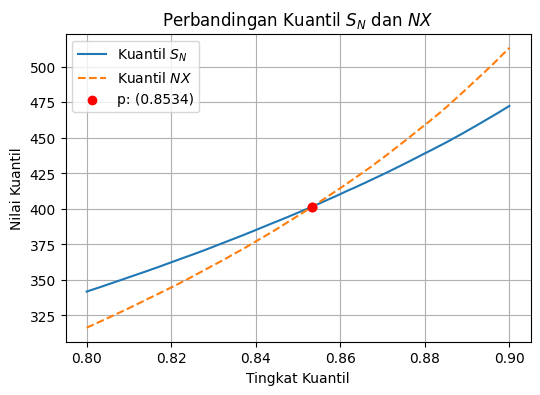

In [ ]:
# @title Default title text
quantile_levels = np.linspace(0.8, 0.9, 1000)
s_n_quantiles = np.quantile(s_n_samples, quantile_levels)
nx_quantiles = np.quantile(nx_samples, quantile_levels)
diff = np.abs(s_n_quantiles - nx_quantiles)
closest_index = np.argmin(diff)

# Mengambil level kuantil dan nilai kuantil yang paling berdekatan
optimal_quantile_level = quantile_levels[closest_index]
optimal_s_n_quantile = s_n_quantiles[closest_index]
optimal_nx_quantile = nx_quantiles[closest_index]


# Verifikasi visual dengan plot
plt.figure(figsize=(6, 4))
plt.plot(quantile_levels, s_n_quantiles, label='Kuantil $S_N$')
plt.plot(quantile_levels, nx_quantiles, label='Kuantil $NX$', linestyle='--')
plt.scatter(optimal_quantile_level, optimal_s_n_quantile, color='red', zorder=5, label=f'p: {optimal_quantile_level:.4f}')
plt.scatter(optimal_quantile_level, optimal_nx_quantile, color='red', zorder=5) # Menandai titik di kurva NX juga
plt.xlabel('Tingkat Kuantil')
plt.ylabel('Nilai Kuantil')
plt.title('Perbandingan Kuantil $S_N$ dan $NX$')
plt.legend()
plt.grid(True)
plt.show()

Tingkat kuantil/selang kepercayaan tersebut yaitu $p \approx 0.8534$. Berikut merupakan perbandingan nilai *Value-at-Risk* dan *Expected Shortfall* pada selang kepercayaan $90\%, 95\%,97.5\%$ dan $99\%$

In [ ]:
# @title Default title text
import numpy as np
import pandas as pd

# Calculate quantiles
quantiles = [0.9, 0.95, 0.975, 0.99]
s_n_quantiles = np.quantile(s_n_samples, quantiles)
nx_quantiles = np.quantile(nx_samples, quantiles)

# Calculate Expected Shortfall (ES)
def expected_shortfall(data, alpha):
    """Calculates the Expected Shortfall (Conditional Value at Risk)."""
    # Sort the data in ascending order
    sorted_data = np.sort(data)
    # Find the index corresponding to the VaR level
    index = int(np.ceil(len(sorted_data) * alpha))
    # Calculate the average of values beyond the VaR level
    if index < len(sorted_data):
        es = np.mean(sorted_data[index:])
    else:
        es = sorted_data[-1] # If alpha is 1, ES is the max value
    return es

s_n_es = [expected_shortfall(s_n_samples, q) for q in quantiles]
nx_es = [expected_shortfall(nx_samples, q) for q in quantiles]

# Create a DataFrame for the results
results = pd.DataFrame({
    'Level': quantiles,
    'VaR(S_N)': s_n_quantiles,
    'S_N Expected Shortfall': s_n_es,
    'VaR(NX)': nx_quantiles,
    'NX Expected Shortfall': nx_es
})

# Display the table
print("Quantil dan Expected Shortfall")
print(results.to_string(index=False))

Quantil dan Expected Shortfall
 Quantile Level   VaR(S_N)  S_N Expected Shortfall     VaR(NX)  NX Expected Shortfall
          0.900 471.956040              643.072796  514.660301             865.943512
          0.950 594.427067              759.145451  737.973980            1120.987624
          0.975 711.985284              871.442108  985.758447            1396.368306
          0.990 862.142103             1014.358017 1338.075942            1789.050546


Perhatikan bahwa untuk tingkat kepercayaan yang sama dan lebih dari $p$, besar *Value-at-Risk* untuk model 1 lebih kecil daripada model 2. Dengan kata lain, potensi agregat kerugian terbesar pada model 2 lebih besar daripada model 1. Hal ini juga berdampak pada rata-rata agregat kerugian dalam kasus terburuk yang mungkin terjadi pada model 2 lebih besar dari model 1.

Akibatnya, cadangan yang harus disediakan untuk produk yang menggunakan model 2 lebih besar daripada produk yang menggunakan model 1. Memang, dengan cadangan yang lebih besar kesehatan perusahaan lebih terjamin tetapi modal awal yang diperlukan menjadi lebih besar.

Dari pembuktian secara teoritis dan simulasi, jelas bahwa distribusi $S_N$ `tidak sama (identik)` dengan distribusi $S^{(2)}_N$

# **B. Kapan Kedua Model dikatakan Identik**

Secara intuitif, $S^{(2)}_N=NX$ akan terjadi jika setiap pengamatan $X_i, i=1,2,...,N$ memiliki nilai realisasi yang sama yaitu realisasi $X_1=x_1$. Karena $X_i$ menyatakan besar klaim maka besar klaim kedua, ketiga dan ke-$N$ bergantung pada besar klaim pertama yaitu $x_1$. Hal ini berarti $X_i$ tidak saling bebas atau $corr(X_i,X_j) \ne 0$ untuk $i\ne j$. Bahkan dapat diketahui bahwa $corr(X_i,X_j)=1$ akibat dari $X_i=X_j$.

Jadi $X_1+X_2+...+X_N=NX$ jika $X_i=X_j$ atau $corr(X_i,X_j)=1$



# **C. Ekspreksi yang sesuai untuk $S_N=X_1+X_2+...+S_N$?**

Perhatikan bahwa
\begin{align}
S_N &= X_1+X2+...+X_N \\
&= N \frac{X_1+X_2+...+X_N}{N} \\
&= N\cdot \bar{X}
\end{align}
Sehingga ekspresi yang sesuai untuk mewakili $S_N$ yaitu $S_N=N\cdot \bar{X}$ dengan $\bar{X}$ merupakan peubah acak rata-rata kerugian.

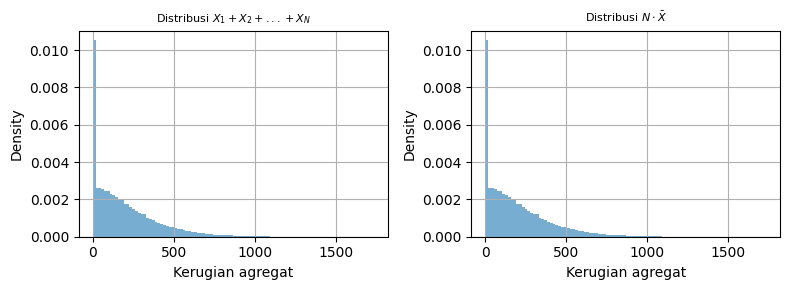

In [ ]:
# @title Default title text
import numpy as np
import matplotlib.pyplot as plt

# Jumlah simulasi
simulasi = 100000

# Parameter
lambda_poisson = 2           # rata-rata klaim
scale_expon = 100            # eksponensial (mean = 100 → scale = 100)

# Simulasi jumlah klaim N
N = np.random.poisson(lam=lambda_poisson, size=simulasi)

# Simulasi total kerugian S = sum X_i untuk tiap N
total_loss = []
average_loss = []

for n in N:
    if n == 0:
        total_loss.append(0)
        average_loss.append(0)
    else:
        X = np.random.exponential(scale=scale_expon, size=n)
        total_loss.append(np.sum(X))
        average_loss.append(np.mean(X))

total_loss = np.array(total_loss)
average_loss = np.array(average_loss)

# Perkalian N * X̄
approx_loss = N * average_loss

# Plotting
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(total_loss, bins=100, density=True, alpha=0.6, label="Total Loss $S = \\sum X_i$")
plt.title('Distribusi $X_1+X_2+...+X_N$', size=8)
plt.xlabel('Kerugian agregat')
plt.ylabel('Density')
#plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.hist(approx_loss, bins=100, density=True, alpha=0.6, label="Approximated $N \\cdot \\bar{X}$")
plt.title('Distribusi $N \\cdot \\bar{X}$', size=8)
plt.xlabel('Kerugian agregat')
plt.ylabel('Density')
#plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


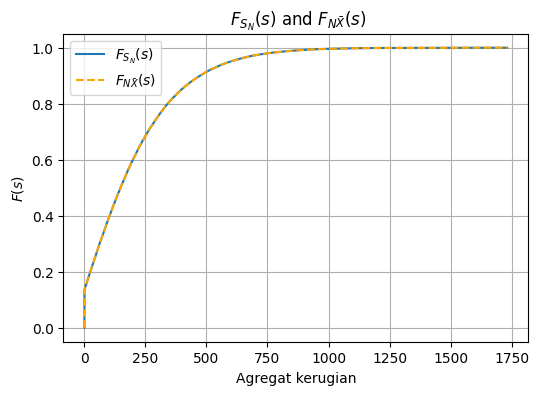

In [ ]:
# @title Default title text
plt.figure(figsize=(6, 4))

# Cumulative distribution for s_n_samples
sorted_s_n = np.sort(total_loss)
cumulative_s_n = np.arange(len(sorted_s_n)) / float(len(sorted_s_n))
plt.plot(sorted_s_n, cumulative_s_n, label='$F_{S_N}(s)$')

# Cumulative distribution for nx_samples
sorted_nx = np.sort(approx_loss)
cumulative_nx = np.arange(len(sorted_nx)) / float(len(sorted_nx))
plt.plot(sorted_nx, cumulative_nx, label='$F_{N\\bar{X}}(s)$', linestyle='--', color='orange')

plt.title(' $F_{S_N}(s)$ and $F_{N\\bar{X}}(s)$')
plt.xlabel('Agregat kerugian')
plt.ylabel('$F(s)$')
plt.legend()
plt.grid(True)
plt.show()

Berdasarkan hasil plot fungsi peluang dan fungsi distribusi, dapat dikonfirmasi bahwa keduanya memiliki distribusi yang sama sehingga $S_N \approx N\cdot \bar{X}$

# **D. Simpulan**

Berdasarkan hasil yang telah diperoleh, secara umum $X_1+X_2+...+X_N$ tidak identik dengan $NX$. Keduanya dikatakan sama jika $corr(X_i,X_j)=1$ dengan kata lain realisasi $X_2, X_3, ...,X_N$ bergantung pada realisasi $X_1$ dan nlainya sama. Ekspresi yang sesuai untuk meringkas agregat kerugian $X_1+X_2+...+X_N$ yaitu $N\cdot \bar{X}$ dengan $\bar{X}$ merupakan peubah acak yang menyatakan rata-rata agregat kerugian.

End of Code